In [36]:
# ============================================
# Cell 1: Imports, warnings, and global setup
# ============================================

import json
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

warnings.filterwarnings("ignore")

# Make plots easier to read in Visual Studio / Jupyter.
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

# Define the project root exactly as requested.
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
META_DIR = REPORT_DIR / "metadata"

for folder in [DATA_DIR, RAW_DIR, PROCESSED_DIR, REPORT_DIR, FIG_DIR, META_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Define the research windows exactly from the specification.
TRAIN_START = "2015-01-01"
TRAIN_END = "2024-12-31"
LIVE_START = "2025-01-01"
LIVE_END = "2026-03-01"

# Download a slightly earlier start date to support later rolling features cleanly.
BUFFER_START = "2014-01-01"
DOWNLOAD_END = LIVE_END

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Download window: {BUFFER_START} to {DOWNLOAD_END}")

Project root: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha
Data directory: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data
Download window: 2014-01-01 to 2026-03-01


In [37]:
# ==========================================================
# Cell 2: Helper functions for downloading and data hygiene
# ==========================================================

def flatten_yfinance_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    yfinance can return MultiIndex columns depending on version and arguments.
    This function flattens them into single-level columns safely.
    """
    if isinstance(df.columns, pd.MultiIndex):
        flattened = []
        for col in df.columns:
            parts = [str(x) for x in col if str(x) != ""]
            flattened.append("_".join(parts))
        df.columns = flattened
    return df


def standardize_ohlcv_columns(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    """
    Standardize OHLCV columns for a single ticker dataset.
    The function is defensive against different yfinance output shapes.
    """
    df = df.copy()
    df = flatten_yfinance_columns(df)

    rename_map = {}
    for col in df.columns:
        col_lower = col.lower()

        if "open" == col_lower or col_lower.endswith("_open"):
            rename_map[col] = f"{prefix}_open"
        elif "high" == col_lower or col_lower.endswith("_high"):
            rename_map[col] = f"{prefix}_high"
        elif "low" == col_lower or col_lower.endswith("_low"):
            rename_map[col] = f"{prefix}_low"
        elif "close" == col_lower or col_lower.endswith("_close"):
            rename_map[col] = f"{prefix}_close"
        elif "adj close" == col_lower or col_lower.endswith("_adj close") or col_lower.endswith("_adj_close"):
            rename_map[col] = f"{prefix}_adj_close"
        elif "volume" == col_lower or col_lower.endswith("_volume"):
            rename_map[col] = f"{prefix}_volume"

    df = df.rename(columns=rename_map)

    # Keep only the standardized columns that exist.
    expected_order = [
        f"{prefix}_open",
        f"{prefix}_high",
        f"{prefix}_low",
        f"{prefix}_close",
        f"{prefix}_adj_close",
        f"{prefix}_volume",
    ]
    keep_cols = [c for c in expected_order if c in df.columns]
    df = df[keep_cols].copy()

    return df


def standardize_single_series(df: pd.DataFrame, prefix: str, preferred_field: str = "Close") -> pd.DataFrame:
    """
    Standardize a one-series macro dataset such as VIX or Treasury yield.
    We keep the close if available because it is the most stable daily reference.
    """
    df = df.copy()
    df = flatten_yfinance_columns(df)

    candidate_columns = []
    for col in df.columns:
        col_lower = col.lower()
        if preferred_field.lower() == col_lower or col_lower.endswith(f"_{preferred_field.lower()}"):
            candidate_columns.append(col)

    if not candidate_columns:
        # Fall back to adjusted close, then close-like fields, then first numeric column.
        fallback_priority = []
        for col in df.columns:
            col_lower = col.lower()
            if "adj close" in col_lower or "adj_close" in col_lower:
                fallback_priority.append(col)
        for col in df.columns:
            col_lower = col.lower()
            if "close" in col_lower and col not in fallback_priority:
                fallback_priority.append(col)

        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        for col in numeric_cols:
            if col not in fallback_priority:
                fallback_priority.append(col)

        if not fallback_priority:
            raise ValueError(f"No usable numeric columns found for prefix '{prefix}'.")

        selected_col = fallback_priority[0]
    else:
        selected_col = candidate_columns[0]

    out = df[[selected_col]].copy()
    out.columns = [prefix]
    return out


def ensure_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert index to normalized timezone-naive DatetimeIndex for clean joins.
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    if getattr(df.index, "tz", None) is not None:
        df.index = df.index.tz_localize(None)
    df.index = df.index.normalize()
    return df


def validate_index_integrity(df: pd.DataFrame, name: str) -> None:
    """
    Print key integrity checks so later phases do not inherit hidden data issues.
    """
    print(f"\nIntegrity check for {name}")
    print("-" * 50)
    print(f"Rows: {len(df):,}")
    print(f"Start date: {df.index.min().date()}")
    print(f"End date: {df.index.max().date()}")
    print(f"Is sorted ascending: {df.index.is_monotonic_increasing}")
    print(f"Duplicate timestamps: {int(df.index.duplicated().sum())}")
    print(f"Missing values by column:")
    print(df.isna().sum())


def save_dataframe_with_fallback(df: pd.DataFrame, parquet_path: Path, csv_path: Path) -> None:
    """
    Save parquet when the engine is available. Always save CSV as a fallback.
    This makes the notebook more robust on clean Python environments.
    """
    df.to_csv(csv_path, index=True)
    try:
        df.to_parquet(parquet_path, index=True)
        print(f"Saved Parquet: {parquet_path}")
    except Exception as exc:
        print(f"Parquet save skipped due to environment issue: {exc}")

    print(f"Saved CSV: {csv_path}")

In [38]:
# ============================================
# Cell 3: Download SPY, VIX, and Treasury data
# ============================================

# Symbols selected for daily macro context:
# - SPY: tradable asset
# - ^VIX: implied volatility index
# - ^TNX: 10-year Treasury yield index from Yahoo Finance
TICKERS = {
    "SPY": "SPY",
    "VIX": "^VIX",
    "TNX": "^TNX",
}

downloaded = {}

for name, ticker in TICKERS.items():
    print(f"Downloading {name} ({ticker}) ...")
    df = yf.download(
        ticker,
        start=BUFFER_START,
        end=DOWNLOAD_END,
        auto_adjust=False,
        progress=False,
        threads=False,
    )

    if df.empty:
        raise ValueError(f"Download failed or returned empty data for {ticker}")

    df = ensure_datetime_index(df)
    df = df[~df.index.duplicated(keep="last")].sort_index()

    raw_csv_path = RAW_DIR / f"{name.lower()}_raw.csv"
    df.to_csv(raw_csv_path, index=True)
    print(f"Saved raw file: {raw_csv_path}")

    downloaded[name] = df

print("\nRaw downloads completed successfully.")

Saved raw file: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\raw\spy_raw.csv
Saved raw file: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\raw\vix_raw.csv
Saved raw file: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\raw\tnx_raw.csv

Raw downloads completed successfully.


In [39]:
# =====================================================
# Cell 4: Standardize each dataset into clean structures
# =====================================================

spy_raw = downloaded["SPY"]
vix_raw = downloaded["VIX"]
tnx_raw = downloaded["TNX"]

def standardize_ohlcv_columns(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    """
    Standardize OHLCV columns from yfinance into:
    prefix_open, prefix_high, prefix_low, prefix_close, prefix_adj_close, prefix_volume

    This version directly extracts data from MultiIndex columns and is robust
    to yfinance outputs like:
    ('Open', 'SPY'), ('High', 'SPY'), ..., ('Volume', 'SPY')
    """
    df = df.copy()

    if isinstance(df.columns, pd.MultiIndex):
        extracted = {}

        for col in df.columns:
            field_name = str(col[0]).strip().lower().replace(" ", "_")

            if field_name == "open":
                extracted[f"{prefix}_open"] = df[col]
            elif field_name == "high":
                extracted[f"{prefix}_high"] = df[col]
            elif field_name == "low":
                extracted[f"{prefix}_low"] = df[col]
            elif field_name == "close":
                extracted[f"{prefix}_close"] = df[col]
            elif field_name == "adj_close":
                extracted[f"{prefix}_adj_close"] = df[col]
            elif field_name == "volume":
                extracted[f"{prefix}_volume"] = df[col]

        df = pd.DataFrame(extracted, index=df.index)

    else:
        rename_map = {}

        for col in df.columns:
            col_str = str(col).strip().lower().replace(" ", "_")

            if "adj" in col_str and "close" in col_str:
                rename_map[col] = f"{prefix}_adj_close"
            elif "open" in col_str:
                rename_map[col] = f"{prefix}_open"
            elif "high" in col_str:
                rename_map[col] = f"{prefix}_high"
            elif "low" in col_str:
                rename_map[col] = f"{prefix}_low"
            elif "close" in col_str:
                rename_map[col] = f"{prefix}_close"
            elif "volume" in col_str:
                rename_map[col] = f"{prefix}_volume"

        df = df.rename(columns=rename_map)

        expected_cols = [
            f"{prefix}_open",
            f"{prefix}_high",
            f"{prefix}_low",
            f"{prefix}_close",
            f"{prefix}_adj_close",
            f"{prefix}_volume",
        ]
        df = df[[col for col in expected_cols if col in df.columns]].copy()

    print(f"\nStandardized columns for {prefix}:")
    print(df.columns.tolist())

    return df

# --- SPY STANDARDIZATION ---
spy = standardize_ohlcv_columns(spy_raw, prefix="spy")

print("\n========== DEBUG: SPY STANDARDIZED COLUMNS ==========")
print(spy.columns.tolist())

required_spy_cols = ["spy_open", "spy_high", "spy_low", "spy_close", "spy_volume"]
missing_spy_cols = [col for col in required_spy_cols if col not in spy.columns]

if missing_spy_cols:
    raise ValueError(f"Missing required SPY columns after standardization: {missing_spy_cols}")

# --- MACRO SERIES ---
vix = standardize_single_series(vix_raw, prefix="vix_close", preferred_field="Close")
tnx = standardize_single_series(tnx_raw, prefix="tnx_close", preferred_field="Close")

spy = ensure_datetime_index(spy)
vix = ensure_datetime_index(vix)
tnx = ensure_datetime_index(tnx)

validate_index_integrity(spy, "SPY standardized")
validate_index_integrity(vix, "VIX standardized")
validate_index_integrity(tnx, "TNX standardized")


Standardized columns for spy:
['spy_adj_close', 'spy_close', 'spy_high', 'spy_low', 'spy_open', 'spy_volume']

========== DEBUG: SPY STANDARDIZED COLUMNS ==========
['spy_adj_close', 'spy_close', 'spy_high', 'spy_low', 'spy_open', 'spy_volume']

Integrity check for SPY standardized
--------------------------------------------------
Rows: 3,057
Start date: 2014-01-02
End date: 2026-02-27
Is sorted ascending: True
Duplicate timestamps: 0
Missing values by column:
spy_adj_close    0
spy_close        0
spy_high         0
spy_low          0
spy_open         0
spy_volume       0
dtype: int64

Integrity check for VIX standardized
--------------------------------------------------
Rows: 3,057
Start date: 2014-01-02
End date: 2026-02-27
Is sorted ascending: True
Duplicate timestamps: 0
Missing values by column:
vix_close    0
dtype: int64

Integrity check for TNX standardized
--------------------------------------------------
Rows: 3,056
Start date: 2014-01-02
End date: 2026-02-27
Is sorted as

In [40]:
# ===============================================================
# Cell 5: Align all datasets using the SPY trading calendar only
# ===============================================================

# Important design choice:
# We align everything to SPY's trading days because SPY is the traded instrument.
# This avoids creating artificial rows on non-trading days and keeps execution timing realistic.

master = spy.copy()
master = master.join(vix, how="left")
master = master.join(tnx, how="left")

# Macro series can have exchange/calendar mismatches.
# Forward-fill macro values only after joining to SPY's market-day index.
# This is acceptable because at day t we only use information available up to day t.
macro_cols = ["vix_close", "tnx_close"]
master[macro_cols] = master[macro_cols].ffill()

# We do not forward-fill SPY price or volume fields because missing traded-asset prices
# on a trading day indicate a real data problem that should be investigated.
spy_cols = [c for c in master.columns if c.startswith("spy_")]
if master[spy_cols].isna().any().any():
    missing_spy_rows = master[master[spy_cols].isna().any(axis=1)]
    raise ValueError(
        "SPY contains missing values on SPY trading dates. "
        "This should not be silently filled.\n"
        f"Problem dates:\n{missing_spy_rows.index.tolist()[:10]}"
    )

# Remove any remaining leading rows where macro series were still unavailable.
master = master.dropna(subset=macro_cols).copy()

validate_index_integrity(master, "Master dataset after alignment")
print("\nMaster dataset preview:")
print(master.head())


Integrity check for Master dataset after alignment
--------------------------------------------------
Rows: 3,057
Start date: 2014-01-02
End date: 2026-02-27
Is sorted ascending: True
Duplicate timestamps: 0
Missing values by column:
spy_adj_close    0
spy_close        0
spy_high         0
spy_low          0
spy_open         0
spy_volume       0
vix_close        0
tnx_close        0
dtype: int64

Master dataset preview:
            spy_adj_close   spy_close    spy_high     spy_low    spy_open  \
Date                                                                        
2014-01-02     148.580261  182.919998  184.070007  182.479996  183.979996   
2014-01-03     148.555939  182.889999  183.600006  182.630005  183.229996   
2014-01-06     148.125412  182.360001  183.559998  182.080002  183.490005   
2014-01-07     149.035126  183.479996  183.789993  182.949997  183.089996   
2014-01-08     149.067657  183.520004  183.830002  182.889999  183.449997   

            spy_volume  vix_close  

In [41]:
# ============================================================
# Cell 6: Add basic date partitions for later walk-forward use
# ============================================================

master = master.copy()

master["is_train_period"] = (
    (master.index >= pd.Timestamp(TRAIN_START)) &
    (master.index <= pd.Timestamp(TRAIN_END))
)

master["is_live_period"] = (
    (master.index >= pd.Timestamp(LIVE_START)) &
    (master.index <= pd.Timestamp(LIVE_END))
)

master["dataset_partition"] = np.select(
    [
        master["is_train_period"],
        master["is_live_period"],
    ],
    [
        "train",
        "live",
    ],
    default="buffer_or_unused"
)

print(master["dataset_partition"].value_counts(dropna=False).sort_index())
print("\nPartition date coverage:")
for label in ["buffer_or_unused", "train", "live"]:
    subset = master[master["dataset_partition"] == label]
    if len(subset) > 0:
        print(f"{label}: {subset.index.min().date()} -> {subset.index.max().date()} | rows = {len(subset):,}")

dataset_partition
buffer_or_unused     252
live                 289
train               2516
Name: count, dtype: int64

Partition date coverage:
buffer_or_unused: 2014-01-02 -> 2014-12-31 | rows = 252
train: 2015-01-02 -> 2024-12-31 | rows = 2,516
live: 2025-01-02 -> 2026-02-27 | rows = 289


In [42]:
# ===================================================
# Cell 7: Final validation and descriptive statistics
# ===================================================

# Confirm strict chronological ordering and uniqueness.
assert master.index.is_monotonic_increasing, "Index must be sorted in ascending order."
assert master.index.duplicated().sum() == 0, "Duplicate timestamps must be removed."

# Confirm we have the requested periods available.
assert (master.index <= pd.Timestamp(TRAIN_END)).any(), "Training period data is missing."
assert (master.index >= pd.Timestamp(LIVE_START)).any(), "Live simulation period data is missing."

# Basic sanity checks for core columns.
for col in ["spy_open", "spy_high", "spy_low", "spy_close"]:
    assert (master[col] > 0).all(), f"{col} contains non-positive values."

assert (master["vix_close"] > 0).all(), "VIX values should be positive."
assert (master["tnx_close"] > 0).all(), "Treasury yield values should be positive."

summary_stats = master[["spy_open", "spy_high", "spy_low", "spy_close", "spy_volume", "vix_close", "tnx_close"]].describe().T
print(summary_stats)

             count          mean           std           min           25%  \
spy_open    3057.0  3.511080e+02  1.392829e+02  1.747800e+02  2.267000e+02   
spy_high    3057.0  3.529753e+02  1.399554e+02  1.755600e+02  2.274000e+02   
spy_low     3057.0  3.490629e+02  1.384994e+02  1.737100e+02  2.259000e+02   
spy_close   3057.0  3.511649e+02  1.392978e+02  1.741700e+02  2.267400e+02   
spy_volume  3057.0  8.799021e+07  4.453763e+07  2.027000e+07  6.008590e+07   
vix_close   3057.0  1.797933e+01  6.922147e+00  9.140000e+00  1.341000e+01   
tnx_close   3057.0  2.651299e+00  1.093917e+00  4.990000e-01  1.829000e+00   

                     50%           75%           max  
spy_open    3.030000e+02  4.397800e+02  6.970500e+02  
spy_high    3.049600e+02  4.418500e+02  6.978400e+02  
spy_low     3.004100e+02  4.375700e+02  6.939400e+02  
spy_close   3.032100e+02  4.396600e+02  6.954900e+02  
spy_volume  7.681190e+07  1.023251e+08  5.072443e+08  
vix_close   1.618000e+01  2.069000e+01  8.269

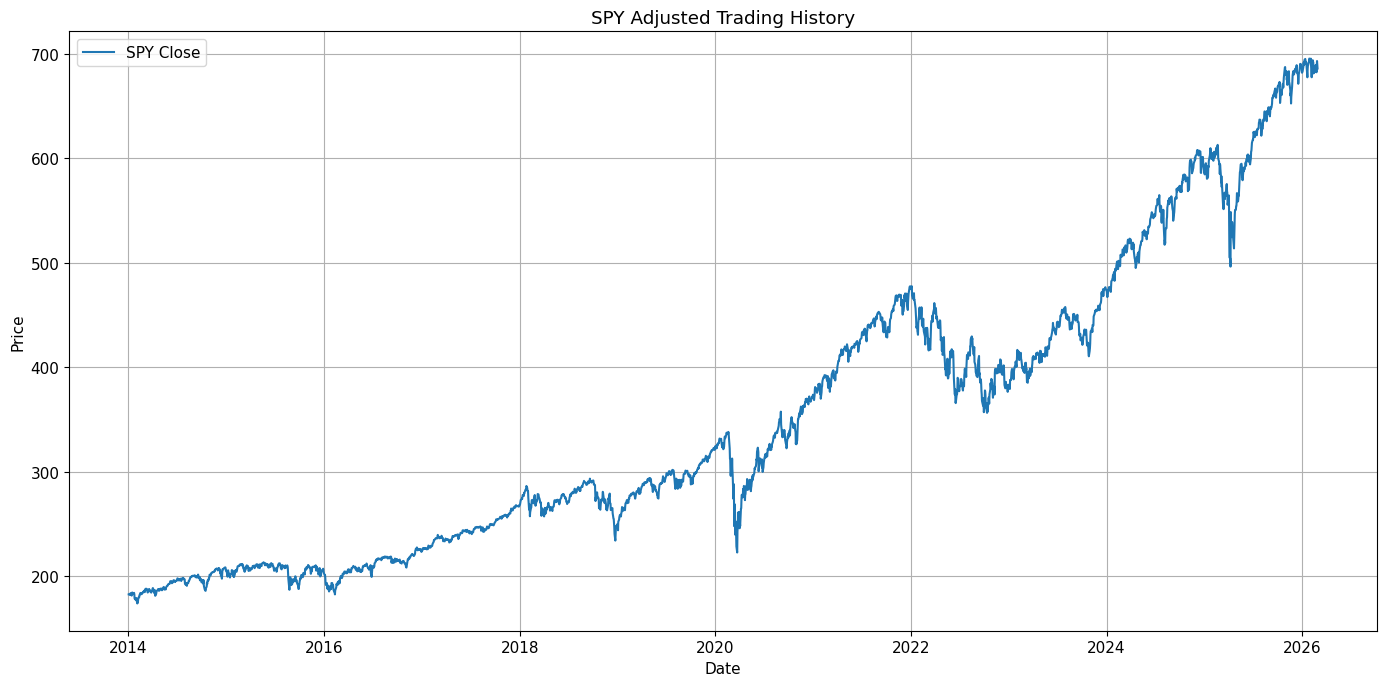

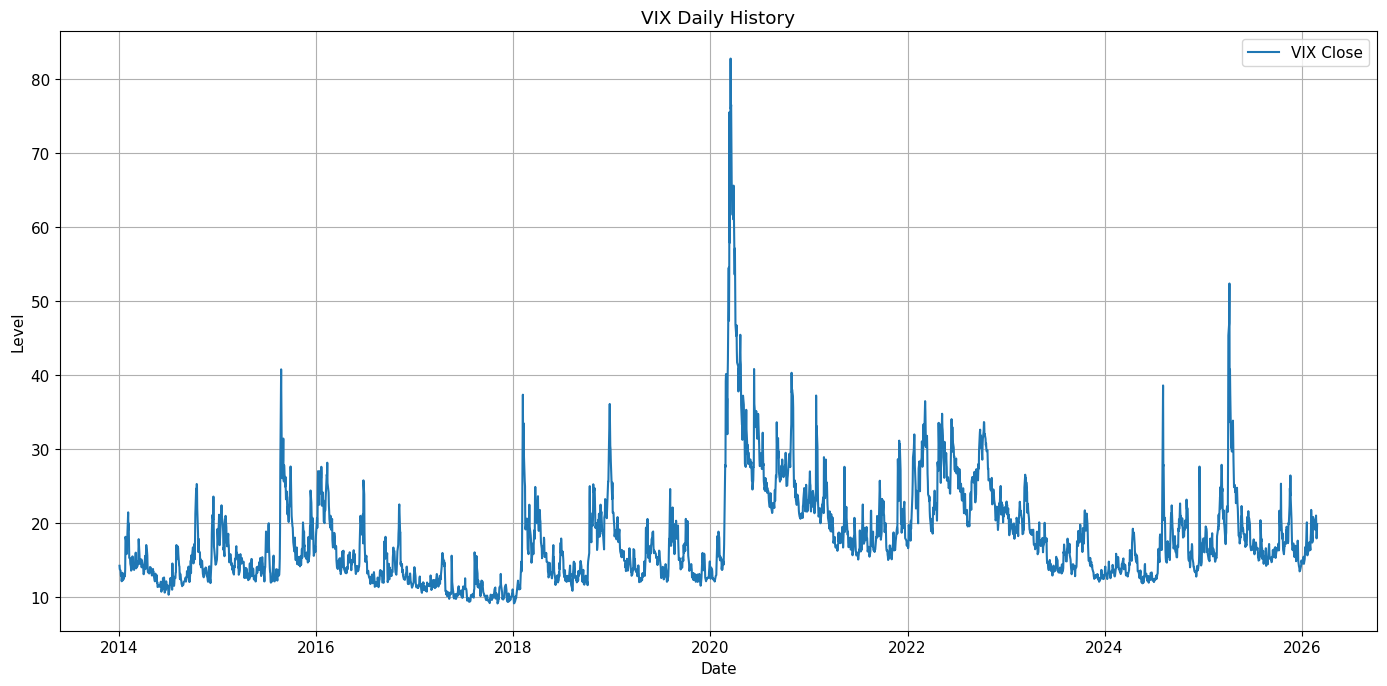

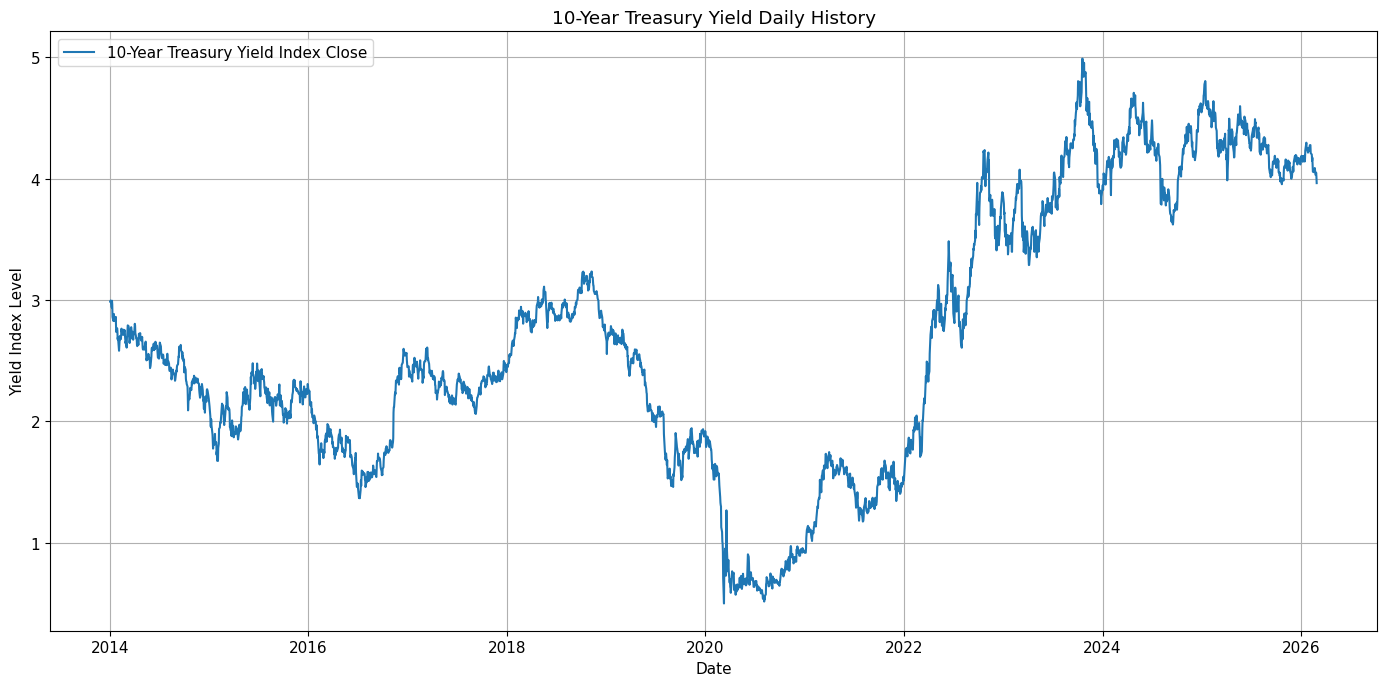

In [43]:
# ===========================================
# Cell 8: Visualization for data inspection
# ===========================================

fig, ax = plt.subplots()
ax.plot(master.index, master["spy_close"], label="SPY Close")
ax.set_title("SPY Adjusted Trading History")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_1_spy_close.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
ax.plot(master.index, master["vix_close"], label="VIX Close")
ax.set_title("VIX Daily History")
ax.set_xlabel("Date")
ax.set_ylabel("Level")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_1_vix_close.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
ax.plot(master.index, master["tnx_close"], label="10-Year Treasury Yield Index Close")
ax.set_title("10-Year Treasury Yield Daily History")
ax.set_xlabel("Date")
ax.set_ylabel("Yield Index Level")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_1_tnx_close.png", dpi=150)
plt.show()

In [44]:
# ============================================
# Cell 9: Save outputs for Phase 2 and later notebook use
# ============================================

print("Current working directory:")
print(Path.cwd())

print("\nProject root:")
print(PROJECT_ROOT)

print("\nProcessed directory:")
print(PROCESSED_DIR)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
META_DIR.mkdir(parents=True, exist_ok=True)

master_csv_path = PROCESSED_DIR / "phase_1_master_data.csv"
master_parquet_path = PROCESSED_DIR / "phase_1_master_data.parquet"

print("\nAbout to save files to:")
print(master_csv_path)
print(master_parquet_path)

save_dataframe_with_fallback(master, master_parquet_path, master_csv_path)

metadata = {
    "phase": "Phase 1 - Data Engineering & Integrity Layer",
    "created_from_notebook": "1 - Data Engineering & Integrity Layer.ipynb",
    "final_row_count": int(len(master)),
    "final_column_count": int(master.shape[1]),
    "columns": master.columns.tolist(),
    "start_date": str(master.index.min().date()),
    "end_date": str(master.index.max().date()),
    "duplicate_timestamps": int(master.index.duplicated().sum()),
    "missing_values_by_column": {k: int(v) for k, v in master.isna().sum().to_dict().items()},
}

metadata_path = META_DIR / "phase_1_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print(f"\nSaved metadata: {metadata_path}")

print("\nFiles now in processed directory:")
for f in PROCESSED_DIR.iterdir():
    print(f.name)

Current working directory:
c:\Users\Tyler\Regime-Aware Risk Integrated Alpha

Project root:
c:\Users\Tyler\Regime-Aware Risk Integrated Alpha

Processed directory:
c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed

About to save files to:
c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_1_master_data.csv
c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_1_master_data.parquet
Saved Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_1_master_data.parquet
Saved CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_1_master_data.csv

Saved metadata: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\reports\metadata\phase_1_metadata.json

Files now in processed directory:
phase_1_master_data.csv
phase_1_master_data.parquet


In [45]:
# ============================================
# Cell 10: Phase 2 loader snippet
# ============================================

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

csv_path = PROCESSED_DIR / "phase_1_master_data.csv"
parquet_path = PROCESSED_DIR / "phase_1_master_data.parquet"

print("Looking for Phase 1 files:")
print("CSV:", csv_path)
print("Parquet:", parquet_path)

if parquet_path.exists():
    df = pd.read_parquet(parquet_path)
    print("Loaded Parquet file")
elif csv_path.exists():
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    print("Loaded CSV file")
else:
    raise FileNotFoundError("Phase 1 data file not found.")

df.index = pd.to_datetime(df.index)
df = df.sort_index()

print("\nLoaded dataset preview:")
print(df.head())

Looking for Phase 1 files:
CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_1_master_data.csv
Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_1_master_data.parquet
Loaded Parquet file

Loaded dataset preview:
            spy_adj_close   spy_close    spy_high     spy_low    spy_open  \
Date                                                                        
2014-01-02     148.580261  182.919998  184.070007  182.479996  183.979996   
2014-01-03     148.555939  182.889999  183.600006  182.630005  183.229996   
2014-01-06     148.125412  182.360001  183.559998  182.080002  183.490005   
2014-01-07     149.035126  183.479996  183.789993  182.949997  183.089996   
2014-01-08     149.067657  183.520004  183.830002  182.889999  183.449997   

            spy_volume  vix_close  tnx_close  is_train_period  is_live_period  \
Date                                                                            
2014-01-02   119636900      14